In [18]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import streamlit as st
import random
import math
import time
import heapq

In [19]:
bbox = [-65.0897, -42.7959, -64.9932, -42.7494]
polygon = ox.utils_geo.bbox_to_poly(bbox)
graph = ox.graph_from_polygon(polygon, network_type="drive")

In [23]:
st.title("A* Visualizer")

start = st.selectbox("Origen", list(graph.nodes))
end = st.selectbox("Destino", list(graph.nodes))

run = st.button("Ejecutar")

placeholder = st.empty()
metrics = st.empty()

def streamlit_callback(state):
    # dibujar con tu función existente
    fig = plot_graph()  # ⚠️ asegurate que devuelva fig
    placeholder.pyplot(fig)

    metrics.metric("Paso", state["step"])
    metrics.metric("Visitados", len(state["visited"]))

    time.sleep(0.02)  # velocidad

if run:
    found = a_star(start, end, on_step=streamlit_callback)

    if found:
        path = get_path(end)
        st.write("Camino encontrado:", len(path), "nodos")
    else:
        st.error("No se encontró camino")

2026-04-23 20:41:55.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.294 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.295 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 20:41:55.299 Session state does not function when running a script without `streamlit run`
2026-04-23 20:41

In [4]:
# from https://github.com/santifiorino/maps-pathfinding/
for edge in graph.edges:
    # Cleaning the "maxspeed" attribute, some values are lists, some are strings, some are None
    maxspeed = 40
    if "maxspeed" in graph.edges[edge]:
        maxspeed = graph.edges[edge]["maxspeed"]
        if type(maxspeed) == list:
            speeds = [ int(speed) for speed in maxspeed ]
            maxspeed = min(speeds)
        elif type(maxspeed) == str:
            maxspeed = int(maxspeed)
    graph.edges[edge]["maxspeed"] = maxspeed
    # Adding the "weight" attribute (time = distance / speed)
    graph.edges[edge]["weight"] = graph.edges[edge]["length"] / maxspeed

In [5]:
# from https://github.com/santifiorino/maps-pathfinding/
def style_unvisited_edge(edge):        
    graph.edges[edge]["color"] = "#d36206"
    graph.edges[edge]["alpha"] = 0.2
    graph.edges[edge]["linewidth"] = 0.5

def style_visited_edge(edge):
    graph.edges[edge]["color"] = "#d36206"
    graph.edges[edge]["alpha"] = 1
    graph.edges[edge]["linewidth"] = 1

def style_active_edge(edge):
    graph.edges[edge]["color"] = '#e8a900'
    graph.edges[edge]["alpha"] = 1
    graph.edges[edge]["linewidth"] = 1

def style_path_edge(edge):
    graph.edges[edge]["color"] = "white"
    graph.edges[edge]["alpha"] = 1
    graph.edges[edge]["linewidth"] = 1

In [6]:
def plot_graph():
    ox.plot_graph(
        graph,
        node_size =  [ graph.nodes[node]["size"] for node in graph.nodes ],
        edge_color = [ graph.edges[edge]["color"] for edge in graph.edges ],
        edge_alpha = [ graph.edges[edge]["alpha"] for edge in graph.edges ],
        edge_linewidth = [ graph.edges[edge]["linewidth"] for edge in graph.edges ],
        node_color = "white",
        bgcolor = "#18080e"
    )

In [7]:
# from https://github.com/santifiorino/maps-pathfinding/
def plot_heatmap(algorithm):
    edge_colors = ox.plot.get_edge_colors_by_attr(graph, f"{algorithm}_uses", cmap="hot")
    fig, _ = ox.plot_graph(
        graph,
        node_size = 0,
        edge_color = edge_colors,
        bgcolor = "#18080e"
    )

In [8]:
# from https://github.com/santifiorino/maps-pathfinding/
def reconstruct_map(orig, dest, plot=False, algorithm=None):
    for edge in graph.edges:
        style_unvisited_edge(edge)
    dist = 0
    speeds = []
    curr = dest
    while curr != orig:
        prev = graph.nodes[curr]["previous"]
        dist += graph.edges[(prev, curr, 0)]["length"]
        speeds.append(graph.edges[(prev, curr, 0)]["maxspeed"])
        style_path_edge((prev, curr, 0))
        if algorithm:
            graph.edges[(prev, curr, 0)][f"{algorithm}_uses"] = graph.edges[(prev, curr, 0)].get(f"{algorithm}_uses", 0) + 1
        curr = prev
    dist /= 1000
    if plot:
        print(f"Distance: {dist}")
        print(f"Avg. speed: {sum(speeds)/len(speeds)}")
        print(f"Total time: {dist/(sum(speeds)/len(speeds)) * 60}")
        plot_graph()

In [9]:
# from https://github.com/santifiorino/maps-pathfinding/
def reconstruct_path(orig, dest, plot=False, algorithm=None):
    for edge in graph.edges:
        style_unvisited_edge(edge)
    dist = 0
    speeds = []
    curr = dest
    while curr != orig:
        prev = graph.nodes[curr]["previous"]
        dist += graph.edges[(prev, curr, 0)]["length"]
        speeds.append(graph.edges[(prev, curr, 0)]["maxspeed"])
        style_path_edge((prev, curr, 0))
        if algorithm:
            graph.edges[(prev, curr, 0)][f"{algorithm}_uses"] = graph.edges[(prev, curr, 0)].get(f"{algorithm}_uses", 0) + 1
        curr = prev
    dist /= 1000
    if plot:
        print(f"Distance: {dist}")
        print(f"Avg. speed: {sum(speeds)/len(speeds)}")
        print(f"Total time: {dist/(sum(speeds)/len(speeds)) * 60}")
        plot_graph()

In [10]:
def get_coords(node):
    data = graph.nodes[node]
    return data["x"], data["y"]

In [11]:
def haversine_form(lat1, lon1, lat2, lon2):
    R = 6371000
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = math.sin(dlat / 2)**2 + \
        math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

In [12]:
def euclidean_distance(orig, dest):
    x1, y1 = get_coords(orig)
    x2, y2 = get_coords(dest)
    return ((x2 - x1)**2 + (y2 - y1)**2)**0.5

In [13]:
def manhattan_distance(orig, dest):
    x1, y1 = get_coords(orig)
    x2, y2 = get_coords(dest)
    return abs(x2 - x1) + abs(y2 - y1)

In [14]:
def haversine_distance(orig, dest):
    x1, y1 = get_coords(orig)
    x2, y2 = get_coords(dest)

#    orig_coords = (math.radians(x), math.radians(coord1[1]))

    lat1, lon1 = math.radians(x1), math.radians(y1)
    lat2, lon2 = math.radians(x2), math.radians(y2)
    
    return haversine_form(lat1, lon1, lat2, lon2)

In [15]:
def a_star(orig, dest, plot=False, on_step=None):
    for node in graph.nodes:
        graph.nodes[node]["previous"] = None
        graph.nodes[node]["size"] = 0
        graph.nodes[node]["g_score"] = float("inf")
        graph.nodes[node]["f_score"] = float("inf")
    for edge in graph.edges:
        style_unvisited_edge(edge)
    graph.nodes[orig]["size"] = 50
    graph.nodes[dest]["size"] = 50
    graph.nodes[orig]["g_score"] = 0
    graph.nodes[orig]["f_score"] = haversine_distance(orig, dest)
    pq = [(graph.nodes[orig]["f_score"], orig)]
    step = 0
    while pq:
        _, node = heapq.heappop(pq)
        visited.add(node)
        
        if on_step:
            on_step({
                "step": step,
                "current": node,
                "visited": visited.copy(),
                "done": False
            })
        if node == dest:
            if plot:
                print("Iteraciones:", step)
                time.sleep(0.05)
                plot_graph()

            if on_step:
                on_step({
                    "step": step,
                    "current": node,
                    "visited": visited,
                    "done": True
                })
            return
        for edge in graph.out_edges(node):
            style_visited_edge((edge[0], edge[1], 0))
            neighbor = edge[1]
            tentative_g_score = graph.nodes[node]["g_score"] + haversine_distance(node, neighbor)
            if tentative_g_score < graph.nodes[neighbor]["g_score"]:
                graph.nodes[neighbor]["previous"] = node
                graph.nodes[neighbor]["g_score"] = tentative_g_score
                graph.nodes[neighbor]["f_score"] = tentative_g_score + haversine_distance(neighbor, dest)
                heapq.heappush(pq, (graph.nodes[neighbor]["f_score"], neighbor))
                for edge2 in graph.out_edges(neighbor):
                    style_active_edge((edge2[0], edge2[1], 0))
        step += 1

In [16]:
# from https://github.com/santifiorino/maps-pathfinding/
def dijkstra(orig, dest, plot=False):
    for node in graph.nodes:
        graph.nodes[node]["visited"] = False
        graph.nodes[node]["distance"] = float("inf")
        graph.nodes[node]["previous"] = None
        graph.nodes[node]["size"] = 0
    for edge in graph.edges:
        style_unvisited_edge(edge)
    graph.nodes[orig]["distance"] = 0
    graph.nodes[orig]["size"] = 50
    graph.nodes[dest]["size"] = 50
    pq = [(0, orig)]
    step = 0
    while pq:
        _, node = heapq.heappop(pq)
        if node == dest:
            if plot:
                print("Iteraciones:", step)
                plot_graph()
            return
        if graph.nodes[node]["visited"]: continue
        graph.nodes[node]["visited"] = True
        for edge in graph.out_edges(node):
            style_visited_edge((edge[0], edge[1], 0))
            neighbor = edge[1]
            weight = graph.edges[(edge[0], edge[1], 0)]["weight"]
            if graph.nodes[neighbor]["distance"] > graph.nodes[node]["distance"] + weight:
                graph.nodes[neighbor]["distance"] = graph.nodes[node]["distance"] + weight
                graph.nodes[neighbor]["previous"] = node
                heapq.heappush(pq, (graph.nodes[neighbor]["distance"], neighbor))
                for edge2 in graph.out_edges(neighbor):
                    style_active_edge((edge2[0], edge2[1], 0))
        step += 1

Start: 12952008383
End: 8399748034
Iteraciones: 2738


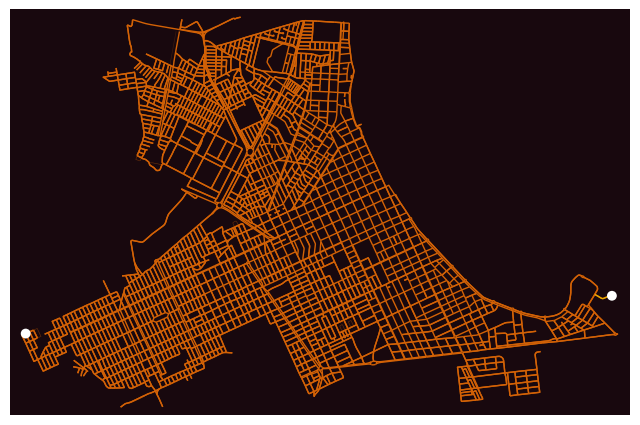

Distance: 9.771705006898554
Avg. speed: 42.5
Total time: 13.795348245033251


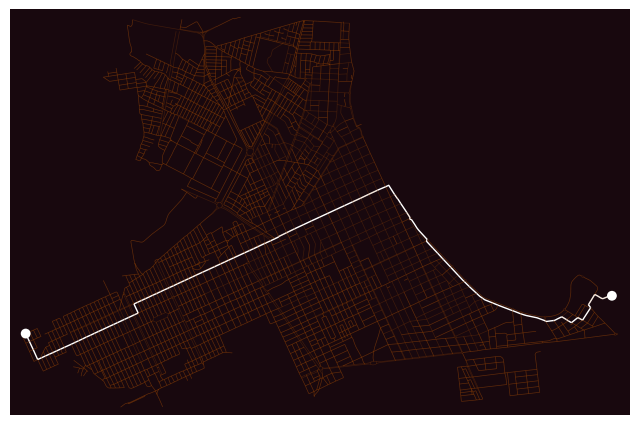

In [63]:
#start = random.choice(list(graph.nodes))
#end = random.choice(list(graph.nodes))
start_point, end_point = (-150.7648893, 18.0417802), (42.7818757, 649966722)
#start = ox.nearest_nodes(graph, X=start_point[0], Y=start_point[1])
#end = ox.nearest_nodes(graph, X=end_point[0], Y=end_point[1])
print("Start:", start)
print("End:", end)
#start 1376899175
#end 1376422205
#start_point, end_point = (42.7648893, 65.0417802), (42.7818757, 649966722)
#start_point, end_point = (-150.7648893, 18.0417802), (42.7818757, 649966722)

dijkstra(start, end, plot=True)
reconstruct_path(start, end, plot=True)